In [2]:
!pip install pandas missingno seaborn numpy

In [3]:
# ============================================================
# EDA: UCI Air Quality — Missing Data Analysis
# ============================================================
# Dataset: Air Quality Chemical Multisensor Device
# Location: Italian city, road level, polluted area
# Period:   March 2004 – February 2005 (1 year, hourly)
# Sensors:  5 metal oxide chemical sensors
# Special:  Missing values marked as -200 (not NaN!)
#
# This notebook focuses on MISSING DATA PATTERNS —
# the primary reason this dataset exists in GridPulse.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'

# --- Load data ---
# Separator is ;  and decimal is , (European format)
df = pd.read_csv('/content/AirQualityUCI.csv', sep=';', decimal=',')

# Drop trailing empty columns (artifact of the CSV format)
df = df.drop(columns=[c for c in df.columns if 'Unnamed' in str(c)])

# Drop trailing all-NaN rows
df = df.dropna(subset=['Date', 'Time'], how='all')

# Parse datetime
df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'],
                                format='%d/%m/%Y %H.%M.%S')
df = df.drop(columns=['Date', 'Time']).set_index('datetime').sort_index()

# Define column groups
# GT = Ground Truth (reference analyzer), PT08.Sx = sensor readings
gt_cols = ['CO(GT)', 'NMHC(GT)', 'NOx(GT)', 'NO2(GT)']
sensor_cols = ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)',
               'PT08.S4(NO2)', 'PT08.S5(O3)']
env_cols = ['T', 'RH', 'AH']       # Temperature, Relative Humidity, Absolute Humidity
chem_cols = ['C6H6(GT)']            # Benzene (reference)
all_features = gt_cols + sensor_cols + chem_cols + env_cols

print(f"Shape: {df.shape}")
print(f"Period: {df.index.min()} → {df.index.max()}")
print(f"Frequency: hourly ({len(df)} hours ≈ {len(df)/24:.0f} days)")
print(f"\nColumn groups:")
print(f"  Ground Truth (reference):  {gt_cols}")
print(f"  Sensor readings:           {sensor_cols}")
print(f"  Benzene (reference):       {chem_cols}")
print(f"  Environmental:             {env_cols}")

Shape: (9357, 13)
Period: 2004-03-10 18:00:00 → 2005-04-04 14:00:00
Frequency: hourly (9357 hours ≈ 390 days)

Column groups:
  Ground Truth (reference):  ['CO(GT)', 'NMHC(GT)', 'NOx(GT)', 'NO2(GT)']
  Sensor readings:           ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)']
  Benzene (reference):       ['C6H6(GT)']
  Environmental:             ['T', 'RH', 'AH']


In [4]:
# ============================================================
# CRITICAL STEP: Replace -200 with NaN
# ============================================================
# In this dataset, -200 means "missing" — NOT a real value.
# If you forget this step, your model will learn that
# CO concentration can be -200 µg/m³, which is physically
# impossible. This is the #1 mistake people make with this data.
# ============================================================

df_raw = df.copy()   # keep raw version for comparison
df = df.copy()

for col in all_features:
    df[col] = df[col].replace(-200, np.nan)

# Overview of missingness
print("=" * 65)
print(f"{'Column':<18} {'Missing':>7} {'% Missing':>10} {'Category'}")
print("=" * 65)
for col in all_features:
    n = df[col].isna().sum()
    pct = 100 * n / len(df)
    # Categorize severity
    if pct > 50:
        cat = "🔴 UNUSABLE as-is"
    elif pct > 10:
        cat = "🟡 Needs imputation"
    elif pct > 0:
        cat = "🟢 Minor gaps"
    else:
        cat = "✅ Complete"
    print(f"  {col:<16} {n:>7} {pct:>9.1f}%  {cat}")

print(f"\n{'─'*65}")
print(f"Total cells: {len(df) * len(all_features):,}")
print(f"Missing cells: {df[all_features].isna().sum().sum():,} "
      f"({100*df[all_features].isna().sum().sum()/(len(df)*len(all_features)):.1f}%)")

Column             Missing  % Missing Category
  CO(GT)              1683      18.0%  🟡 Needs imputation
  NMHC(GT)            8443      90.2%  🔴 UNUSABLE as-is
  NOx(GT)             1639      17.5%  🟡 Needs imputation
  NO2(GT)             1642      17.5%  🟡 Needs imputation
  PT08.S1(CO)          366       3.9%  🟢 Minor gaps
  PT08.S2(NMHC)        366       3.9%  🟢 Minor gaps
  PT08.S3(NOx)         366       3.9%  🟢 Minor gaps
  PT08.S4(NO2)         366       3.9%  🟢 Minor gaps
  PT08.S5(O3)          366       3.9%  🟢 Minor gaps
  C6H6(GT)             366       3.9%  🟢 Minor gaps
  T                    366       3.9%  🟢 Minor gaps
  RH                   366       3.9%  🟢 Minor gaps
  AH                   366       3.9%  🟢 Minor gaps

─────────────────────────────────────────────────────────────────
Total cells: 121,641
Missing cells: 16,701 (13.7%)


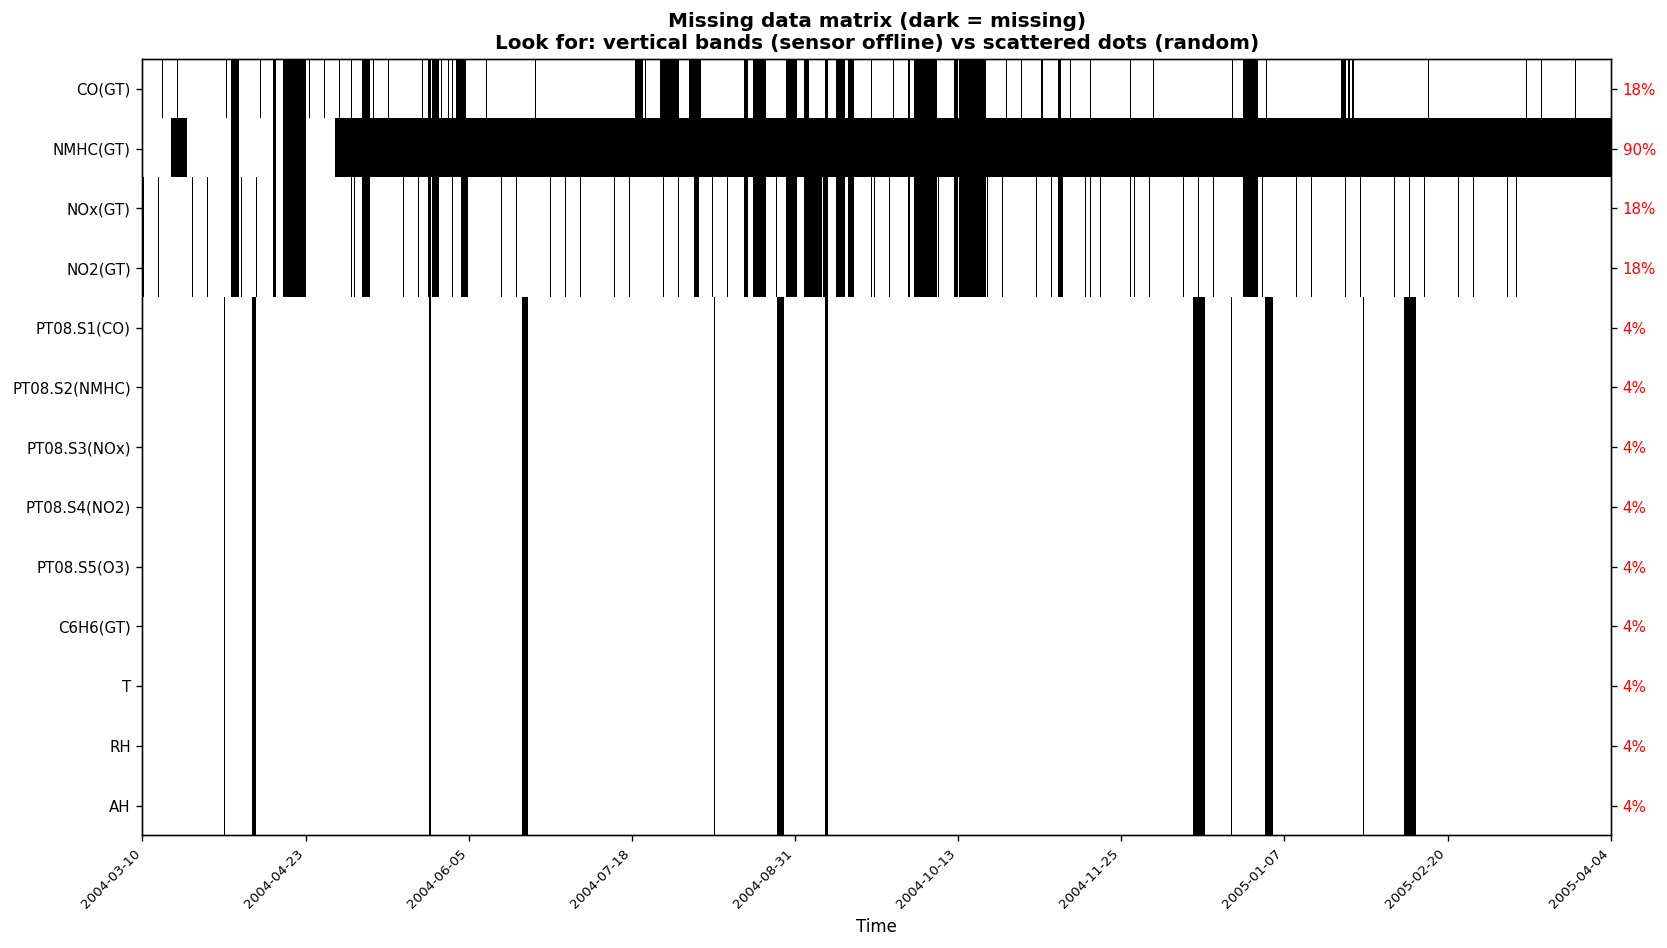

OBSERVATIONS:
  1. NMHC(GT) — 90% missing. Practically unusable without heavy imputation.
  2. CO(GT), NOx(GT), NO2(GT) — ~18% missing, clearly in BLOCKS (vertical bands).
  3. All sensor columns (PT08.Sx) + T/RH/AH — 3.9% missing, SAME rows.
     → 366 hours where the ENTIRE sensor device was offline.
  4. Missing is NOT random — it occurs in concentrated time periods.


In [5]:
# ============================================================
# PART A: MISSING PATTERN VISUALIZATION
# ============================================================
# Two views:
# 1. missingno matrix — shows WHERE missing values are in time
# 2. Custom heatmap  — shows WHEN (by day × hour) missing occurs
#
# Key question: Is missing RANDOM or in BLOCKS?
# If blocks → sensor went offline → pattern is informative
# If random → measurement noise → easier to impute
# ============================================================

# --- View 1: missingno-style matrix (manual implementation) ---
# Each column = one feature, each row = one time point
# White = present, Dark = missing

fig, ax = plt.subplots(figsize=(14, 8))

# Create binary missing matrix (1 = missing, 0 = present)
missing_matrix = df[all_features].isna().astype(int)

# Plot using imshow for efficiency (9357 rows × 13 cols)
ax.imshow(missing_matrix.values.T, aspect='auto', cmap='gray_r',
          interpolation='none', vmin=0, vmax=1)

ax.set_yticks(range(len(all_features)))
ax.set_yticklabels(all_features, fontsize=9)

# Time axis labels
n_ticks = 10
tick_positions = np.linspace(0, len(df)-1, n_ticks, dtype=int)
tick_labels = [df.index[i].strftime('%Y-%m-%d') for i in tick_positions]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=8)

ax.set_title('Missing data matrix (dark = missing)\n'
             'Look for: vertical bands (sensor offline) vs scattered dots (random)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Time')

# Add right-side bar showing % missing per column
ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())
ax2.set_yticks(range(len(all_features)))
pct_labels = [f"{100*df[c].isna().mean():.0f}%" for c in all_features]
ax2.set_yticklabels(pct_labels, fontsize=9, color='red')

plt.tight_layout()
plt.show()

print("OBSERVATIONS:")
print("  1. NMHC(GT) — 90% missing. Practically unusable without heavy imputation.")
print("  2. CO(GT), NOx(GT), NO2(GT) — ~18% missing, clearly in BLOCKS (vertical bands).")
print("  3. All sensor columns (PT08.Sx) + T/RH/AH — 3.9% missing, SAME rows.")
print("     → 366 hours where the ENTIRE sensor device was offline.")
print("  4. Missing is NOT random — it occurs in concentrated time periods.")

CO(GT):
  Blocks: 187, lengths: min=1, max=173, median=1
  Short (≤6h): 160, Medium (7-24h): 9, Long (>24h): 18

NOx(GT):
  Blocks: 344, lengths: min=1, max=173, median=1
  Short (≤6h): 323, Medium (7-24h): 4, Long (>24h): 17

NO2(GT):
  Blocks: 344, lengths: min=1, max=173, median=1
  Short (≤6h): 323, Medium (7-24h): 4, Long (>24h): 17

PT08.S1(CO):
  Blocks: 16, lengths: min=1, max=76, median=10
  Short (≤6h): 6, Medium (7-24h): 5, Long (>24h): 5



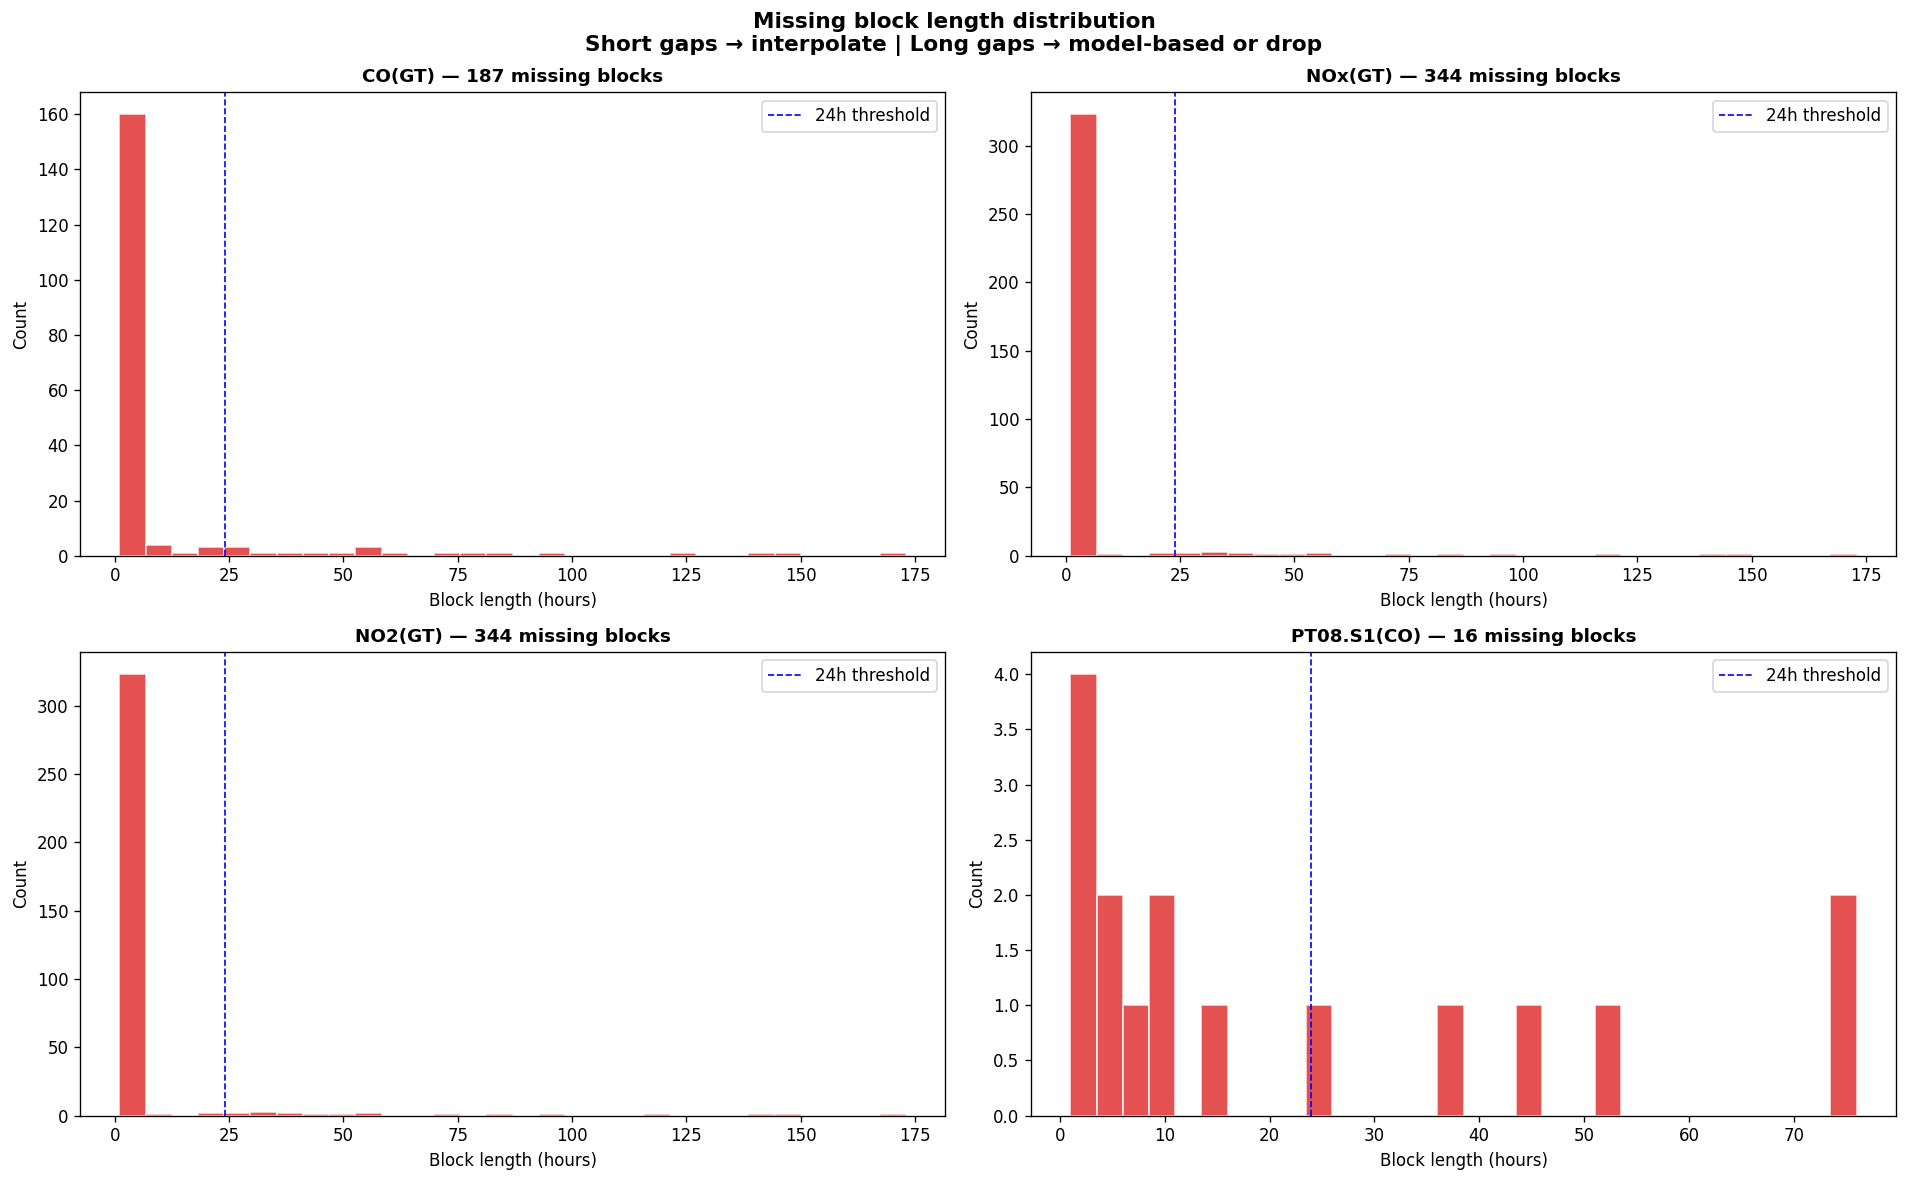

In [6]:
# ============================================================
# How long are the missing blocks?
# This determines which imputation methods are viable:
#   - 1-2 hours gap → linear interpolation works fine
#   - 6-12 hours    → need seasonal-aware method
#   - 24+ hours     → need model-based imputation (KNN, MICE, LSTM)
#   - 100+ hours    → very hard, consider dropping the segment
# ============================================================

def find_missing_blocks(series):
    """Find consecutive missing blocks and return their lengths and start positions."""
    is_miss = series.isna().astype(int)
    blocks = []
    start = None
    count = 0
    for i, val in enumerate(is_miss):
        if val == 1:
            if start is None:
                start = i
            count += 1
        else:
            if count > 0:
                blocks.append({'start': start, 'length': count,
                               'start_time': series.index[start]})
            start = None
            count = 0
    if count > 0:
        blocks.append({'start': start, 'length': count,
                       'start_time': series.index[start]})
    return pd.DataFrame(blocks)

# Analyze key columns
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
analyze_cols = ['CO(GT)', 'NOx(GT)', 'NO2(GT)', 'PT08.S1(CO)']

for idx, col in enumerate(analyze_cols):
    ax = axes[idx // 2][idx % 2]
    blocks = find_missing_blocks(df[col])

    if len(blocks) > 0:
        # Histogram of block lengths
        ax.hist(blocks['length'], bins=30, color='#dc2626', edgecolor='white', alpha=0.8)
        ax.axvline(24, color='blue', linestyle='--', linewidth=1, label='24h threshold')
        ax.set_title(f'{col} — {len(blocks)} missing blocks', fontsize=11, fontweight='bold')
        ax.set_xlabel('Block length (hours)')
        ax.set_ylabel('Count')
        ax.legend()

        # Print summary
        print(f"{col}:")
        print(f"  Blocks: {len(blocks)}, "
              f"lengths: min={blocks['length'].min()}, "
              f"max={blocks['length'].max()}, "
              f"median={blocks['length'].median():.0f}")
        print(f"  Short (≤6h): {(blocks['length'] <= 6).sum()}, "
              f"Medium (7-24h): {((blocks['length'] > 6) & (blocks['length'] <= 24)).sum()}, "
              f"Long (>24h): {(blocks['length'] > 24).sum()}")
        print()

fig.suptitle('Missing block length distribution\n'
             'Short gaps → interpolate | Long gaps → model-based or drop',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

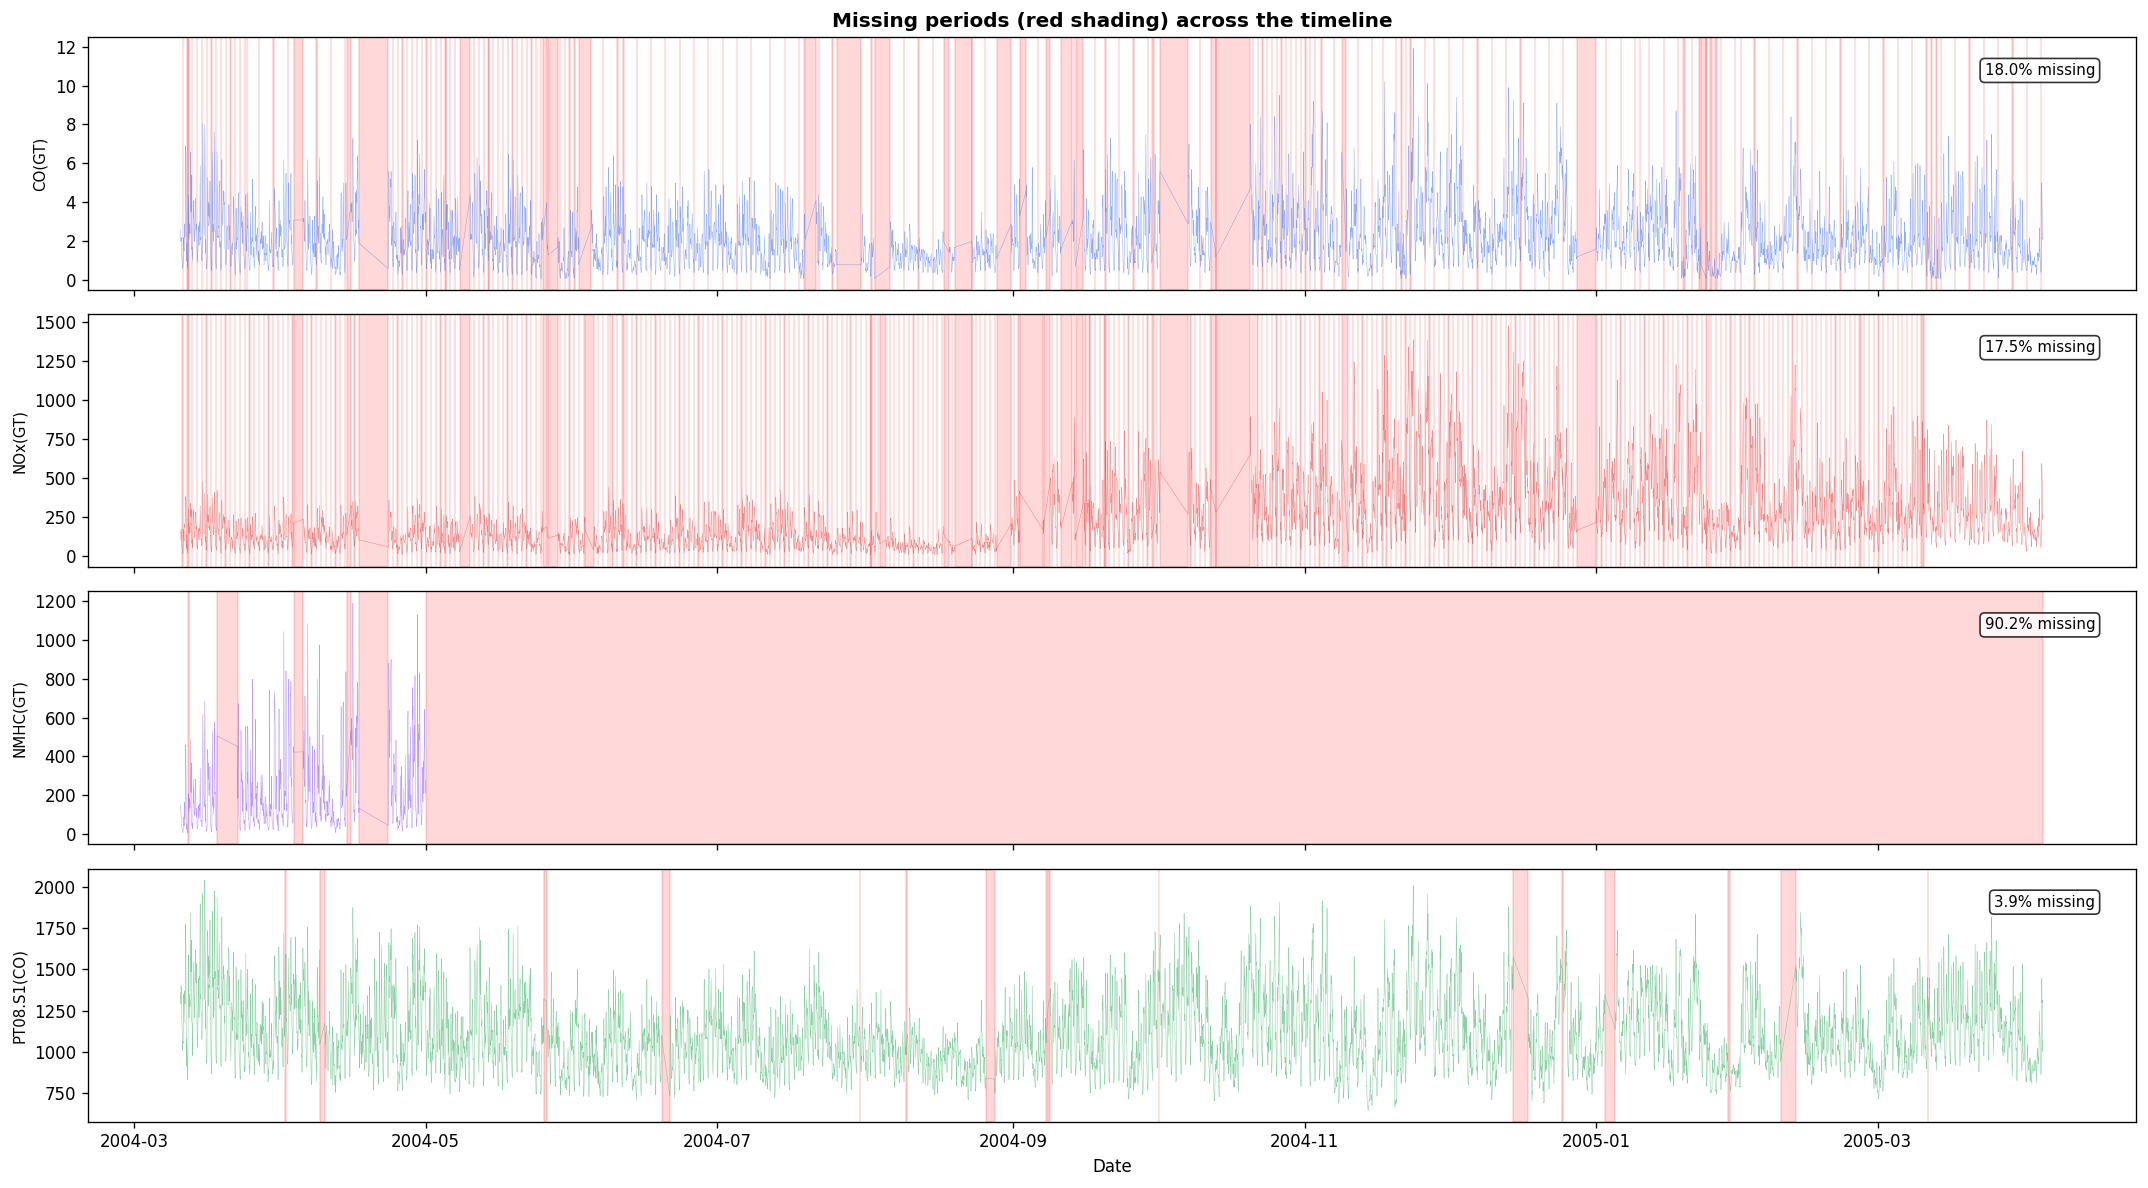

KEY FINDING:
  Missing blocks cluster in specific time periods — this is NOT random.
  The sensor device likely experienced outages, maintenance windows,
  or calibration periods. This is typical of real-world sensor data.


In [7]:
# ============================================================
# When do the missing blocks occur in the timeline?
# This reveals if missingness is concentrated in specific periods
# (e.g., summer maintenance, holiday shutdown, equipment failure)
# ============================================================

fig, axes = plt.subplots(4, 1, figsize=(18, 10), sharex=True)
plot_cols = ['CO(GT)', 'NOx(GT)', 'NMHC(GT)', 'PT08.S1(CO)']
colors = ['#2563eb', '#dc2626', '#7c3aed', '#16a34a']

for idx, (col, color) in enumerate(zip(plot_cols, colors)):
    ax = axes[idx]

    # Plot actual values
    valid = df[col].dropna()
    ax.plot(valid.index, valid.values, linewidth=0.3, color=color, alpha=0.5)

    # Highlight missing periods with red background spans
    is_miss = df[col].isna()
    blocks = find_missing_blocks(df[col])
    for _, block in blocks.iterrows():
        start_t = block['start_time']
        end_idx = min(block['start'] + block['length'], len(df) - 1)
        end_t = df.index[end_idx]
        ax.axvspan(start_t, end_t, color='red', alpha=0.15)

    ax.set_ylabel(col, fontsize=9)
    miss_pct = 100 * is_miss.mean()
    ax.text(0.98, 0.85, f'{miss_pct:.1f}% missing',
            transform=ax.transAxes, ha='right', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

axes[0].set_title('Missing periods (red shading) across the timeline',
                   fontsize=12, fontweight='bold')
axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

print("KEY FINDING:")
print("  Missing blocks cluster in specific time periods — this is NOT random.")
print("  The sensor device likely experienced outages, maintenance windows,")
print("  or calibration periods. This is typical of real-world sensor data.")

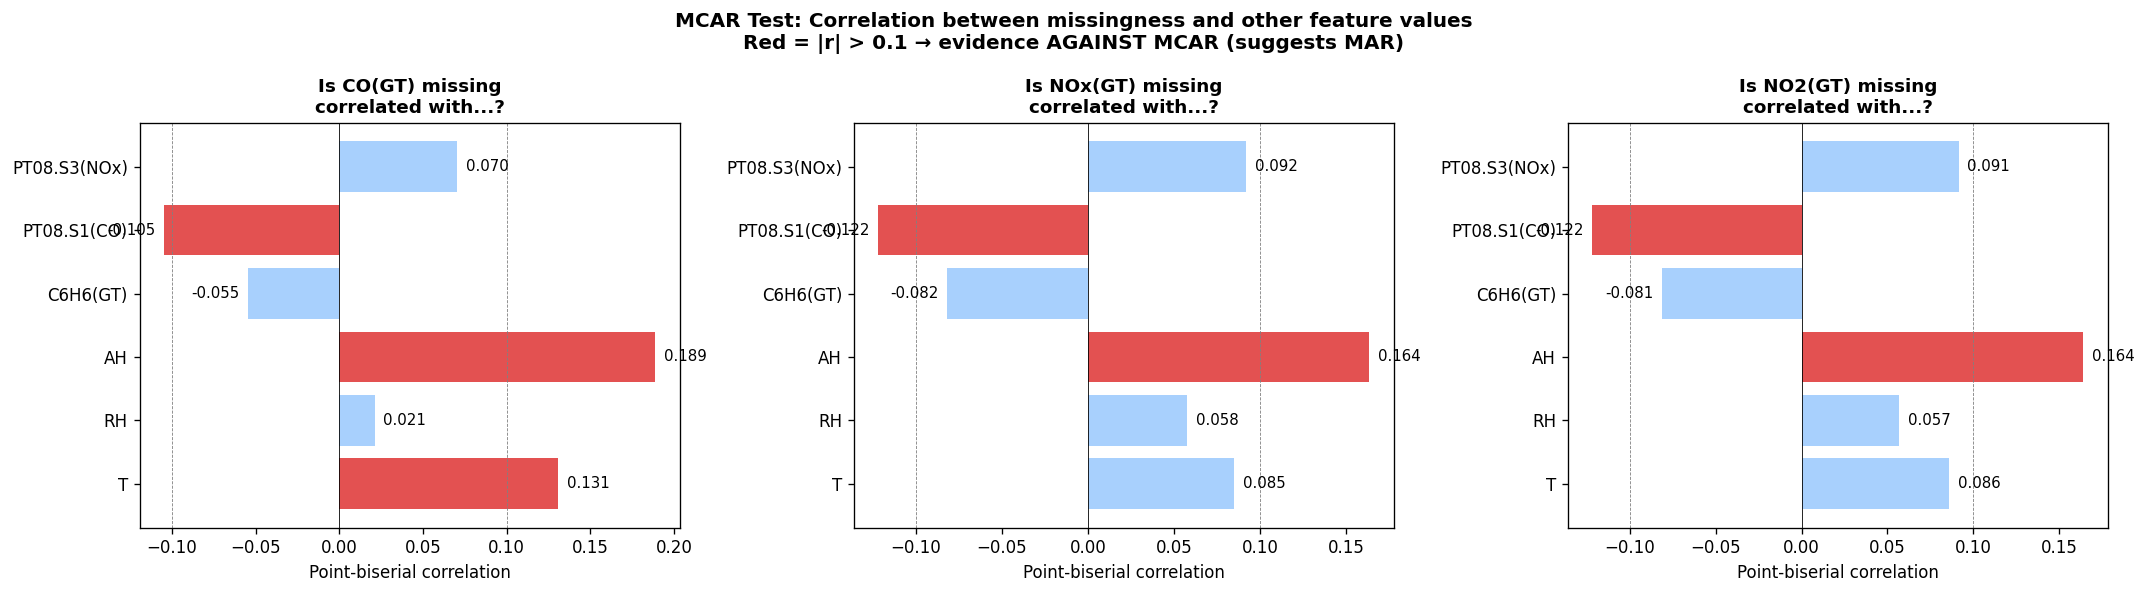

In [8]:
# ============================================================
# PART B: MISSING MECHANISM ANALYSIS
# ============================================================
# Three types of missing data:
#
# MCAR (Missing Completely At Random):
#   Missingness is independent of ALL values (observed & unobserved).
#   Example: lab tech randomly drops test tubes.
#   Test: missingness of column A should NOT correlate with values of column B.
#
# MAR (Missing At Random):
#   Missingness depends on OBSERVED values in other columns.
#   Example: high-pollution hours cause sensor saturation → missing readings.
#   Test: missingness of A correlates with values of B.
#
# MNAR (Missing Not At Random):
#   Missingness depends on the MISSING value itself.
#   Example: sensor fails specifically when CO is very high.
#   Test: distribution of A is different when B is present vs missing.
#
# Why this matters for GridPulse:
#   MCAR → any imputation method works, no systematic bias.
#   MAR  → imputation must use other columns as predictors.
#   MNAR → imputation is inherently biased; need domain-aware methods.
# ============================================================

# --- Test 1: Correlation between missingness of one column and values of others ---
# If MCAR: these correlations should be ~0
# If MAR: significant correlations → missingness depends on observed values

target_cols = ['CO(GT)', 'NOx(GT)', 'NO2(GT)']  # columns with ~18% missing
predictor_cols = ['T', 'RH', 'AH', 'C6H6(GT)', 'PT08.S1(CO)', 'PT08.S3(NOx)']

# Only use rows where predictors are not missing (so we isolate the target's missingness)
mask_predictors_valid = df[predictor_cols].notna().all(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, target in enumerate(target_cols):
    ax = axes[idx]
    subset = df[mask_predictors_valid].copy()
    subset[f'{target}_missing'] = subset[target].isna().astype(int)

    # Point-biserial correlation: binary (missing/not) vs continuous (predictor value)
    correlations = {}
    for pred in predictor_cols:
        r = subset[f'{target}_missing'].corr(subset[pred])
        correlations[pred] = r

    # Plot
    colors_bar = ['#dc2626' if abs(v) > 0.1 else '#93c5fd' for v in correlations.values()]
    bars = ax.barh(list(correlations.keys()), list(correlations.values()),
                   color=colors_bar, alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.axvline(-0.1, color='gray', linewidth=0.5, linestyle='--')
    ax.axvline(0.1, color='gray', linewidth=0.5, linestyle='--')
    ax.set_title(f'Is {target} missing\ncorrelated with...?', fontsize=11, fontweight='bold')
    ax.set_xlabel('Point-biserial correlation')

    for bar, val in zip(bars, correlations.values()):
        ax.text(val + 0.005 if val >= 0 else val - 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

fig.suptitle('MCAR Test: Correlation between missingness and other feature values\n'
             'Red = |r| > 0.1 → evidence AGAINST MCAR (suggests MAR)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

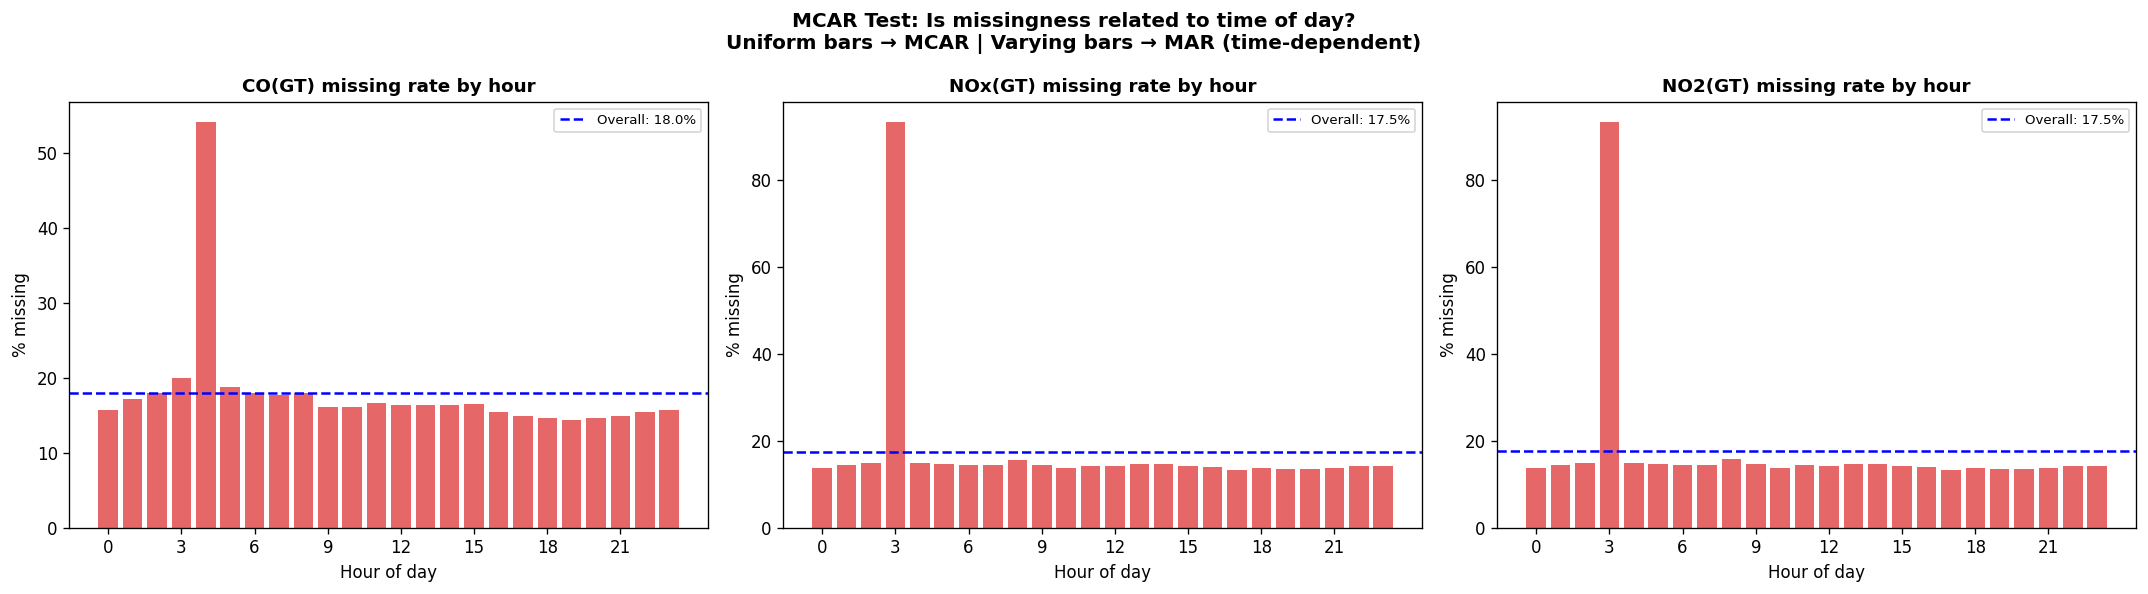

INTERPRETATION:
  If missing rate is roughly the same across all hours → consistent with MCAR.
  If certain hours have much higher missing rates → MAR (time-dependent).
  This affects whether you need time-aware imputation methods.


In [9]:
# --- Test 2: Is missingness related to time of day? ---
# If MCAR: missing should be uniformly distributed across hours
# If MAR/MNAR: certain hours have more missing (e.g., nighttime maintenance)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, col in enumerate(target_cols):
    ax = axes[idx]
    df_temp = df.copy()
    df_temp['hour'] = df_temp.index.hour
    df_temp['is_missing'] = df_temp[col].isna().astype(int)

    # Missing rate per hour
    hourly_miss = df_temp.groupby('hour')['is_missing'].mean() * 100

    ax.bar(hourly_miss.index, hourly_miss.values, color='#dc2626', alpha=0.7)
    ax.axhline(df_temp['is_missing'].mean() * 100, color='blue',
               linestyle='--', label=f'Overall: {df_temp["is_missing"].mean()*100:.1f}%')
    ax.set_title(f'{col} missing rate by hour', fontsize=11, fontweight='bold')
    ax.set_xlabel('Hour of day')
    ax.set_ylabel('% missing')
    ax.set_xticks(range(0, 24, 3))
    ax.legend(fontsize=8)

fig.suptitle('MCAR Test: Is missingness related to time of day?\n'
             'Uniform bars → MCAR | Varying bars → MAR (time-dependent)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("INTERPRETATION:")
print("  If missing rate is roughly the same across all hours → consistent with MCAR.")
print("  If certain hours have much higher missing rates → MAR (time-dependent).")
print("  This affects whether you need time-aware imputation methods.")

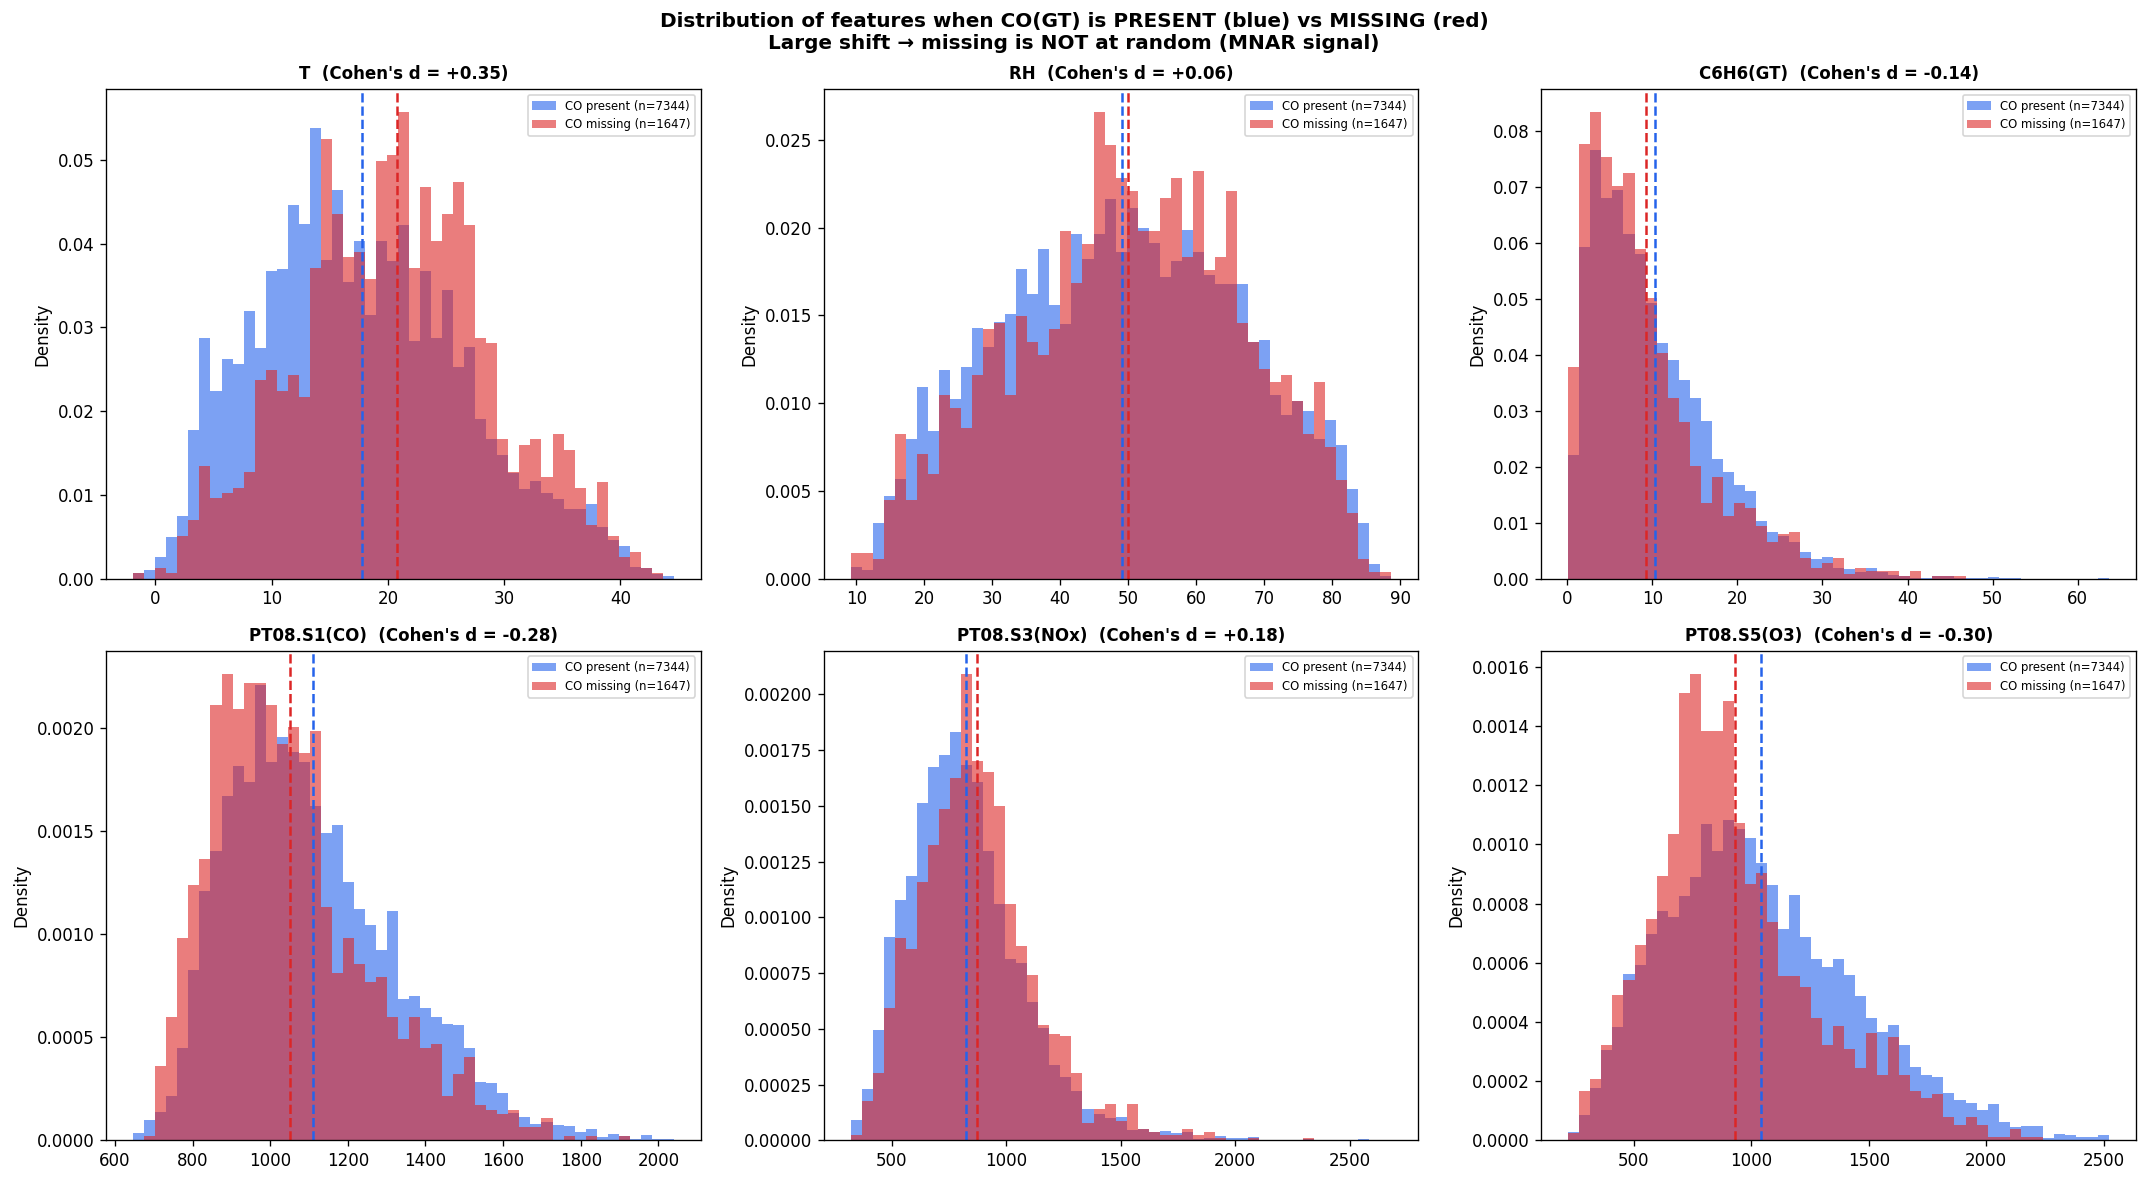

HOW TO READ Cohen's d:
  |d| < 0.2  → negligible difference → consistent with MCAR
  |d| 0.2–0.5 → small difference → weak MAR signal
  |d| 0.5–0.8 → medium difference → MAR likely
  |d| > 0.8  → large difference → strong MAR/MNAR evidence


In [10]:
# ============================================================
# PART C: DISTRIBUTION COMPARISON — COMPLETE vs MISSING CONTEXT
# ============================================================
# The key question: when CO(GT) is missing, are other features
# at their normal levels, or at extreme values?
#
# Method: For each feature X, split into two groups:
#   Group A: X values when CO(GT) is PRESENT
#   Group B: X values when CO(GT) is MISSING
# If distributions differ → MNAR signal (missing depends on conditions)
# If distributions are identical → consistent with MCAR
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

compare_cols = ['T', 'RH', 'C6H6(GT)', 'PT08.S1(CO)', 'PT08.S3(NOx)', 'PT08.S5(O3)']
target = 'CO(GT)'

for idx, col in enumerate(compare_cols):
    ax = axes_flat[idx]

    # Split by whether CO(GT) is missing
    both_valid = df[col].notna()
    co_present = both_valid & df[target].notna()
    co_missing = both_valid & df[target].isna()

    vals_present = df.loc[co_present, col]
    vals_missing = df.loc[co_missing, col]

    # Plot overlapping histograms
    bins = np.linspace(
        min(vals_present.min(), vals_missing.min()),
        max(vals_present.max(), vals_missing.max()),
        50
    )
    ax.hist(vals_present, bins=bins, density=True, alpha=0.6,
            color='#2563eb', label=f'CO present (n={len(vals_present)})')
    ax.hist(vals_missing, bins=bins, density=True, alpha=0.6,
            color='#dc2626', label=f'CO missing (n={len(vals_missing)})')

    # Add vertical mean lines
    ax.axvline(vals_present.mean(), color='#2563eb', linestyle='--', linewidth=1.5)
    ax.axvline(vals_missing.mean(), color='#dc2626', linestyle='--', linewidth=1.5)

    # Effect size (Cohen's d)
    pooled_std = np.sqrt((vals_present.std()**2 + vals_missing.std()**2) / 2)
    cohens_d = (vals_missing.mean() - vals_present.mean()) / pooled_std if pooled_std > 0 else 0

    ax.set_title(f'{col}  (Cohen\'s d = {cohens_d:+.2f})', fontsize=10, fontweight='bold')
    ax.legend(fontsize=7)
    ax.set_ylabel('Density')

fig.suptitle(f'Distribution of features when {target} is PRESENT (blue) vs MISSING (red)\n'
             f'Large shift → missing is NOT at random (MNAR signal)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("HOW TO READ Cohen's d:")
print("  |d| < 0.2  → negligible difference → consistent with MCAR")
print("  |d| 0.2–0.5 → small difference → weak MAR signal")
print("  |d| 0.5–0.8 → medium difference → MAR likely")
print("  |d| > 0.8  → large difference → strong MAR/MNAR evidence")

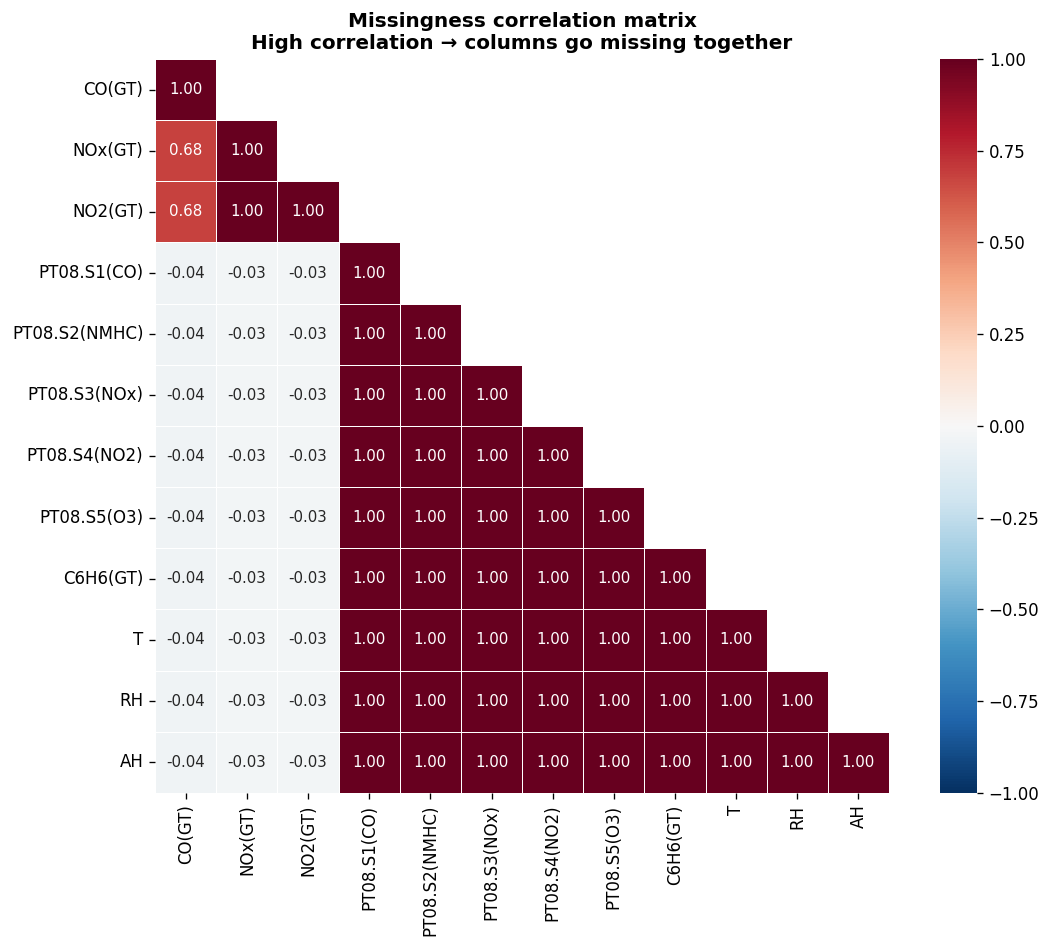

=== Missingness clusters ===

Cluster 1 — Sensor device offline (r ≈ 1.0 with each other):
  PT08.S1(CO), PT08.S2(NMHC), PT08.S3(NOx), PT08.S4(NO2),
  PT08.S5(O3), C6H6(GT), T, RH, AH
  → 366 rows where ALL of these are missing simultaneously.
  → The entire sensor device lost power or was under maintenance.

Cluster 2 — Reference analyzer issues (correlated with each other):
  CO(GT), NOx(GT), NO2(GT)
  → ~18% missing, often in long blocks (up to 173 hours).
  → The reference analyzer had separate, longer outage periods.

IMPUTATION IMPLICATION:
  When sensor columns are missing, you CANNOT use other sensors to impute
  (they're all missing at once). You must use time-based methods
  (interpolation, seasonal patterns) or simply mark and skip those periods.

  When GT columns are missing, you CAN use sensor readings (PT08.Sx)
  to predict the ground truth — this is essentially what the sensors do.


In [11]:
# ============================================================
# BONUS: Do columns go missing TOGETHER?
# If columns have correlated missingness, they likely share
# the same root cause (e.g., same sensor device, same power supply).
# This matters for imputation: you can't use column B to impute
# column A if they're both missing at the same time.
# ============================================================

# Compute correlation of missingness indicators
miss_indicators = df[all_features].isna().astype(int)

# Remove NMHC(GT) from the plot — it's 90% missing, dominates everything
plot_features = [c for c in all_features if c != 'NMHC(GT)']
miss_corr = miss_indicators[plot_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(miss_corr, dtype=bool), k=1)
sns.heatmap(miss_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, square=True, ax=ax,
            vmin=-1, vmax=1, annot_kws={'size': 9},
            linewidths=0.5, linecolor='white')
ax.set_title('Missingness correlation matrix\n'
             'High correlation → columns go missing together',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Identify clusters
print("=== Missingness clusters ===")
print()
print("Cluster 1 — Sensor device offline (r ≈ 1.0 with each other):")
print("  PT08.S1(CO), PT08.S2(NMHC), PT08.S3(NOx), PT08.S4(NO2),")
print("  PT08.S5(O3), C6H6(GT), T, RH, AH")
print("  → 366 rows where ALL of these are missing simultaneously.")
print("  → The entire sensor device lost power or was under maintenance.")
print()
print("Cluster 2 — Reference analyzer issues (correlated with each other):")
print("  CO(GT), NOx(GT), NO2(GT)")
print("  → ~18% missing, often in long blocks (up to 173 hours).")
print("  → The reference analyzer had separate, longer outage periods.")
print()
print("IMPUTATION IMPLICATION:")
print("  When sensor columns are missing, you CANNOT use other sensors to impute")
print("  (they're all missing at once). You must use time-based methods")
print("  (interpolation, seasonal patterns) or simply mark and skip those periods.")
print()
print("  When GT columns are missing, you CAN use sensor readings (PT08.Sx)")
print("  to predict the ground truth — this is essentially what the sensors do.")

In [12]:
# ============================================================
# SUMMARY: What we learned about this dataset's missing data
# ============================================================

print("""
╔══════════════════════════════════════════════════════════════════╗
║              UCI Air Quality — Missing Data Summary             ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  STRUCTURE                                                       ║
║  ─────────                                                       ║
║  • 9,357 hourly readings, 13 features, March 2004 – Feb 2005    ║
║  • -200 markers = missing (must convert to NaN before analysis)  ║
║  • 2 empty trailing columns in CSV (artifact, drop them)         ║
║                                                                  ║
║  MISSING PATTERNS                                                ║
║  ────────────────                                                ║
║  • NMHC(GT): 90% missing → DROP this column entirely             ║
║  • CO(GT), NOx(GT), NO2(GT): ~18% missing, in BLOCKS            ║
║    Max block: 173 hours (>7 days continuous)                     ║
║    18 blocks exceed 24 hours                                     ║
║  • All sensor cols: 3.9% missing, SAME 366 rows                 ║
║    → Entire device offline simultaneously                        ║
║                                                                  ║
║  MISSING MECHANISM                                               ║
║  ─────────────────                                               ║
║  • NOT purely MCAR — missing occurs in time-clustered blocks     ║
║  • Likely MAR — missingness may correlate with environmental     ║
║    conditions (check Cohen's d results above)                    ║
║  • Two separate failure modes:                                   ║
║    1. Sensor device outage (all sensors at once, 366 hours)      ║
║    2. Reference analyzer outage (GT columns, longer blocks)      ║
║                                                                  ║
║  IMPUTATION STRATEGY FOR GRIDPULSE                               ║
║  ─────────────────────────────────                               ║
║  • Drop NMHC(GT) — too sparse to salvage                        ║
║  • Short gaps (≤6h): Linear interpolation or seasonal interp    ║
║  • Medium gaps (7-24h): KNN or MICE using available columns     ║
║  • Long gaps (>24h): LSTM-based imputer or mark as unusable     ║
║  • Sensor-offline periods: Time-based methods only               ║
║    (can't cross-impute, all sensors missing together)            ║
║  • GT-offline periods: Sensor readings → predict GT values       ║
║    (this IS the sensor's job — use regression/ML)                ║
║                                                                  ║
║  NEXT STEP                                                       ║
║  → Phase 5: Implement & compare imputation methods               ║
║  → Evaluate: forecast accuracy on clean vs imputed data          ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║              UCI Air Quality — Missing Data Summary             ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  STRUCTURE                                                       ║
║  ─────────                                                       ║
║  • 9,357 hourly readings, 13 features, March 2004 – Feb 2005    ║
║  • -200 markers = missing (must convert to NaN before analysis)  ║
║  • 2 empty trailing columns in CSV (artifact, drop them)         ║
║                                                                  ║
║  MISSING PATTERNS                                                ║
║  ────────────────                                                ║
║  • NMHC(GT): 90% missing → DROP this column entirely             ║
║  • CO(GT), NOx(GT), NO2(GT): ~18% missing, in BLOCKS            ║
║    Max block: 173 hours (>7 days c